## This time we do it on GPU 

In [ ]:
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import differential_evolution
# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.TDI import *
from Triangle.Data import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

In [ ]:
DATA_DIR = "/home/ps/workspace/TDCData/0_2_MBHB_TDIXYZ.h5"
PARAM_DIR = "/home/ps/workspace/TDCData/0_2_MBHB_parameters.h5"

ORBIT_DIR = "../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB"

## Load data 

In [ ]:
# the path of TDC data 
with h5py.File(DATA_DIR, "r") as h5file: 
    read_dict = read_dict_from_h5(h5file["/"])
    
# the path of parameters 
with h5py.File(PARAM_DIR, "r") as h5file: 
    injected_parameters = read_dict_from_h5(h5file["/"])
    
read_dict.keys(), injected_parameters.keys()

(dict_keys(['XYZ', 'time']),
 dict_keys(['chirp_mass', 'coalescence_phase', 'coalescence_time', 'inclination', 'latitude', 'longitude', 'luminosity_distance', 'mass_ratio', 'psi', 'spin_1z', 'spin_2z']))

### Combine AET and slice data near merger 
Assume that the merger time is roughly located (e.g. by whitening and examining the peak in time-domain data)

In [ ]:
data_time = read_dict["time"]
A2_td, E2_td, _ = AETfromXYZ(read_dict["XYZ"]["X2"], read_dict["XYZ"]["Y2"], read_dict["XYZ"]["Z2"])
data_channels_td = -np.array([A2_td, E2_td]) # the convension of Michelson TDI-2.0 is different from Triangle-Simulator by a minus sign
channel_names = ["A2", "E2"] 

time_idx = np.where(np.abs(data_time/DAY - injected_parameters["coalescence_time"])<2.5)[0]
data_time = data_time[time_idx]
data_channels_td = data_channels_td[:, time_idx]

dt = data_time[1] - data_time[0]
Tobs = len(data_time) * dt 

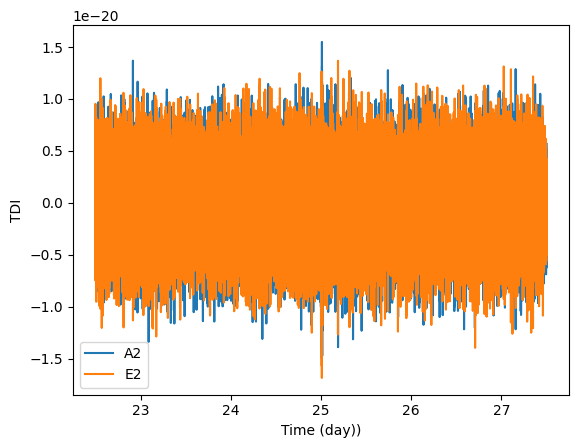

In [ ]:
for i in range(len(data_channels_td)): 
    plt.plot(data_time/DAY, data_channels_td[i], label=channel_names[i])
plt.xlabel("Time (day))")
plt.ylabel("TDI")
plt.legend()

### Fourier transform 

In [ ]:
data_channels_fd = [] 
for i in range(len(data_channels_td)): 
    ff, xf = FFT_window(
        data_array=data_channels_td[i], 
        fsample=1./dt, 
        window_type="tukey", 
        window_args_dict=dict(alpha=1000./Tobs)
    )
    data_channels_fd.append(xf) 
data_channels_fd = np.array(data_channels_fd) * np.exp(-TWOPI * 1.j * ff * data_time[0]) # shift to the "correct" time 
data_frequency = ff 

### Estimate noise PSD

In [ ]:
ff, A2_PSD = PSD_window(
    data_array=A2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)
ff, E2_PSD = PSD_window(
    data_array=E2_td[read_dict["time"]<data_time[0]], 
    fsample=1./dt, 
    window_type="hann", 
    nbin=20
)

psd_func_A2 = CubicSpline(ff, A2_PSD, extrapolate=True)
psd_func_E2 = CubicSpline(ff, E2_PSD, extrapolate=True)
psd_channels = np.array([
    psd_func_A2(data_frequency), 
    psd_func_E2(data_frequency)
])

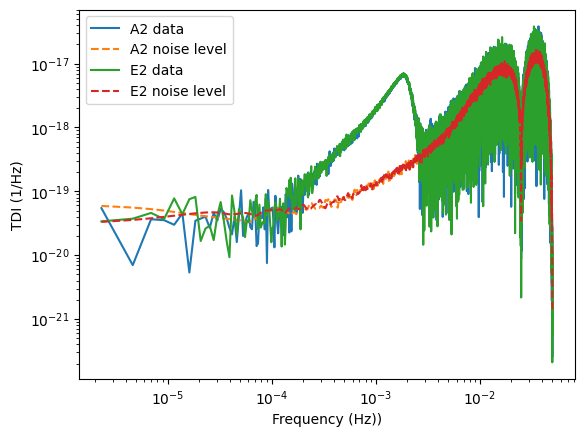

In [ ]:
for i in range(len(data_channels_fd)): 
    plt.loglog(data_frequency, np.abs(data_channels_fd[i]), label=channel_names[i]+" data")
    plt.loglog(data_frequency, np.sqrt(psd_channels[i] * Tobs / 2.), linestyle="--", label=channel_names[i]+" noise level")
plt.xlabel("Frequency (Hz))")
plt.ylabel("TDI (1/Hz)")
plt.legend()

In [ ]:
FMIN = 0.5e-4 
FMAX = 1e-2 
freq_idx = np.where((data_frequency>=FMIN)&(data_frequency<=FMAX))[0]
data_frequency = data_frequency[freq_idx]
data_channels_fd = data_channels_fd[:, freq_idx]
psd_channels = psd_channels[:, freq_idx]

## Models 

### waveform, response and noise

In [ ]:
orbit = Orbit(OrbitDir=ORBIT_DIR)

# initialize  waveform generator 
WFG = BBHxWaveformGenerator(mode="primary", use_gpu=True)

# initialize response generator 
FDTDI = BBHxFDTDIResponseGenerator(orbit_class=orbit, waveform_generator=WFG, use_gpu=True)

# response settings 
response_kwargs_interp = dict(
    modes=[(2,2),], 
    tmin=data_time[0]/DAY,
    tmax=data_time[-1]/DAY, 
    tc_at_constellation=True, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
    drop_T=True, 
    interpolation=True,
)

response_kwargs_direct = response_kwargs_interp.copy()
response_kwargs_direct["interpolation"] = False 

# covariance matrix
CovMat = np.array([
    [psd_channels[0], np.zeros_like(data_frequency)],
    [np.zeros_like(data_frequency), psd_channels[1]],
]) / 4. * Tobs 

# inverse of covmatrix
InvCovMat = np.linalg.inv(np.transpose(CovMat, (2, 0, 1))) 

response_kwargs_interp, InvCovMat.shape 

({'modes': [(2, 2)],
  'tmin': 22.50011574074074,
  'tmax': 27.49988425925926,
  'tc_at_constellation': True,
  'TDIGeneration': '2nd',
  'optimal_combination': True,
  'drop_T': True,
  'interpolation': True},
 (4298, 2, 2))

In [ ]:
# to GPU 
data_frequency = xp.array(data_frequency)
data_channels_fd = xp.array(data_channels_fd)
InvCovMat = xp.array(InvCovMat)

In [ ]:
# wf_channels = FDTDI.Response(
#     parameters=injected_parameters, 
#     freqs=data_frequency, 
#     **response_kwargs_interp, 
# )
# wf_channels_direct = FDTDI.Response(
#     parameters=injected_parameters, 
#     freqs=data_frequency, 
#     **response_kwargs_direct, 
# )
# plt.loglog(data_frequency.get(), np.abs(wf_channels[0].get()))
# plt.loglog(data_frequency.get(), np.abs(wf_channels_direct[0].get()), linestyle="--")
# plt.loglog(data_frequency.get(), np.abs(wf_channels[0].get() - wf_channels_direct[0].get()))

## Search high-likelihood parameters with $\mathcal{F}$-statistics

### set priors for the "intrinsic" parameters (dimension = 11 - 4)

In [ ]:
lgMc_prior = [5., 7.]
q_prior = [0.01, 0.99]
s1_prior = [-0.9, 0.9]
s2_prior = [-0.9, 0.9]
tc_prior = [response_kwargs_direct["tmin"], response_kwargs_direct["tmax"]]
lam_prior = [0, TWOPI]
sinbeta_prior = [-1., 1.]
intrinsic_param_priors = np.array([
    lgMc_prior, 
    q_prior, 
    s1_prior, 
    s2_prior, 
    tc_prior, 
    lam_prior, 
    sinbeta_prior, 
])

### initialize $\mathcal{F}$-statitsitcs

In [ ]:
Fstat = Fstatistics(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_interp, 
    use_gpu=True, 
)

### search in prior 

In [ ]:
def cost_function(norm_int_params):
    """   
        norm_int_params: shape (Nparams, Nevent), normalized to (0, 1)
    """
    try: 
        int_params = norm_int_params.transpose() * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0] # (Nevent, Nparams)
        params_in = Fstat.IntParamArr2ParamDict(int_params.transpose()) # (Nparams, Nevent) -> dictionary, each item (Nevent)
        return -Fstat.calculate_Fstat_vectorized(intrinsic_parameters=params_in) # (Nevent)
    except xp.linalg.LinAlgError:
        return np.infty * np.ones(norm_int_params.shape[1])

n_dim_int = 7 
lower_bounds = np.zeros(n_dim_int) 
upper_bounds = np.ones(n_dim_int) 
bounds = np.array([lower_bounds, upper_bounds]).T # (Nparams, 2)

DE_result = differential_evolution(
    func=cost_function,
    bounds=bounds,
    x0=None,
    strategy='best1exp',
    # strategy='rand1bin',
    maxiter=1000,
    popsize=5*n_dim_int,
    tol=1e-6,
    atol=1e-8,
    mutation=(0.4, 0.95),
    recombination=0.7,
    disp=False,
    vectorized=True,
)
print(DE_result)

/home/ps/miniconda3/envs/tdc/lib/python3.9/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


             message: Optimization terminated successfully.
             success: True
                 fun: -594051.5287666001
                   x: [ 7.383e-01  2.451e-01  7.198e-01  8.393e-01
                        5.022e-01  3.561e-01  1.323e-01]
                 nit: 204
                nfev: 381
          population: [[ 7.383e-01  2.451e-01 ...  3.561e-01  1.323e-01]
                       [ 7.383e-01  2.450e-01 ...  3.554e-01  1.543e-01]
                       ...
                       [ 7.382e-01  2.436e-01 ...  3.697e-01  1.252e-01]
                       [ 7.384e-01  2.458e-01 ...  3.536e-01  1.396e-01]]
 population_energies: [-5.941e+05 -5.941e+05 ... -5.941e+05 -5.941e+05]
                 jac: [ 4.687e+02 -4.221e+01 -2.941e+02 -7.128e+01
                        9.490e+02  1.653e+00 -1.246e+00]


### Reconstruct other parameters and waveform 

In [ ]:
searched_int_params = Fstat.IntParamArr2ParamDict(DE_result.x * (intrinsic_param_priors[:, 1] - intrinsic_param_priors[:, 0]) + intrinsic_param_priors[:, 0])
searched_a = Fstat.calculate_Fstat(
    intrinsic_parameters=searched_int_params, 
    return_a=True, 
) # (1, 4)
searched_ext_params = Fstat.a_to_extrinsic(searched_a)
searched_parameters = dict(searched_int_params, **searched_ext_params)
for k, v in searched_parameters.items(): 
    searched_parameters[k] = float(v)

searched_wf = FDTDI.Response(
    searched_parameters, 
    data_frequency, 
    **response_kwargs_interp, 
)

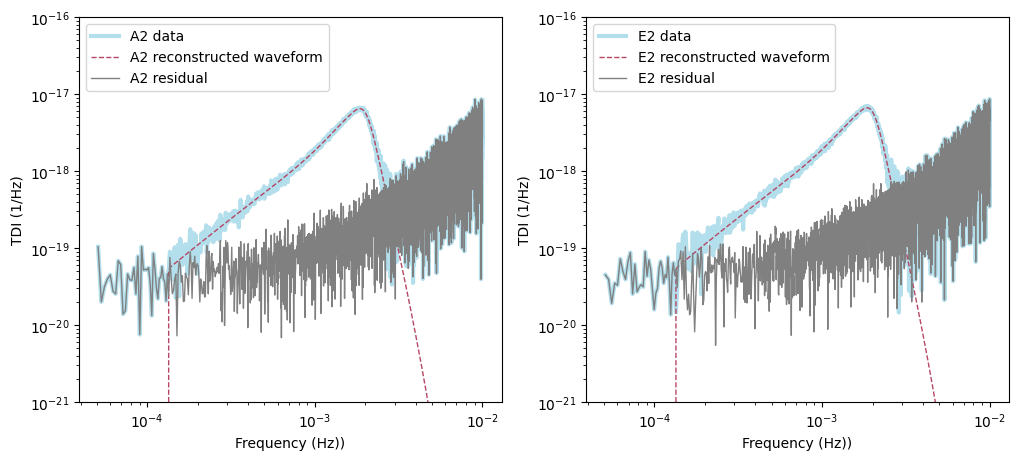

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(len(data_channels_fd)): 
    plt.subplot(121+i)
    plt.loglog(data_frequency.get(), np.abs(data_channels_fd[i].get()), label=channel_names[i]+" data", color=BLUE, linewidth=3, alpha=0.5)
    plt.loglog(data_frequency.get(), np.abs(searched_wf[i].get()), label=channel_names[i]+" reconstructed waveform", color=RED, linewidth=1, linestyle="--")
    plt.loglog(data_frequency.get(), np.abs(data_channels_fd[i].get()-searched_wf[i].get()), label=channel_names[i]+" residual", color="grey", linewidth=1)
    plt.xlabel("Frequency (Hz))")
    plt.ylabel("TDI (1/Hz)")
    plt.legend(loc="upper left")
    plt.ylim(1e-21, 1e-16)

## Fisher analysis around the searched parameters 

In [ ]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        parameters=param_dict, 
        freqs=xp.array(frequencies),  
        **response_kwargs_interp, 
    )
    return res.get()

# set initial steps 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'coalescence_time': 0.001,
    'coalescence_phase': 0.01,
    'luminosity_distance': 10.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=searched_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequency.get(), 
    inverse_covariance=InvCovMat.get(), 
    verbose=0,
)

FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 2462.2990959152658,
 'mass_ratio': 0.001270672920114393,
 'spin_1z': 0.007834017493527447,
 'spin_2z': 0.03584708836302028,
 'coalescence_time': 1.6200230853818938e-05,
 'coalescence_phase': 0.008300698425726234,
 'luminosity_distance': 4401.465796686769,
 'inclination': 0.003530896111608045,
 'longitude': 0.2854302509227362,
 'latitude': 0.25480945245674325,
 'psi': 0.19342336744939279}

## Likelihood

In [ ]:
Like = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequency, 
    data=data_channels_fd, 
    invserse_covariance_matrix=InvCovMat, 
    response_parameters=response_kwargs_direct, 
    use_gpu=True,
)

Like.prepare_het_log_like(base_parameters=ParamDict2ParamArr(searched_parameters))

def eryn_like(params): 
    """params: numpy array of shape (Nevents, Nparams)"""
    # return Like.full_log_like_vectorized(np.transpose(params))
    return Like.het_log_like_vectorized(np.transpose(params))

## Run MCMC 
we use ``Eryn`` which supports vectorized likelihood 

In [ ]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds
from eryn.backends import HDFBackend
from eryn.utils import SearchConvergeStopping

from corner import corner

### set priors around the searched values for intrinsic parameters 

In [ ]:
searched_param_arr = np.array(ParamDict2ParamArr(searched_parameters)) 
injected_param_arr = np.array(ParamDict2ParamArr(injected_parameters)) 
param_names = ['chirp_mass', 'mass_ratio', 'spin_1z', 'spin_2z', 'coalescence_time', 'coalescence_phase', 'luminosity_distance', 'inclination', 'longitude', 'latitude', 'psi']
labels = [r'$\mathcal{M}_{c, z}$', r'$q$', r'$\chi_{z1}$', r'$\chi_{z2}$', r'$t_c$', r'$\varphi_c$', r'$D_L$', r'$\iota$', r'$\lambda$', r'$\beta$', r'$\psi$']

# only the intrisic parameter ranges will be used below 
fim_range = []
for par in param_names:
    if par in ["chirp_mass", "luminosity_distance"]:
        ran = FIM.param_errors[par] / searched_parameters[par] / np.log(10.) # lg value 
    else:
        ran = FIM.param_errors[par] 
    fim_range.append(ran)
fim_range = np.array(fim_range) * 10. # ~10 sigmas

In [ ]:
# set hyper parameters
ndim = 11 # dimension of paramters 
nwalkers = 1000 # number of random walkers
ntemps = 10 # number of temperatures used in parallel tempering 
temps = np.array(list(np.power(2., np.arange(ntemps - 1))) + [np.infty]) 
betas = 1. / temps 
tempering_kwargs=dict(betas=betas)

mcmc_moves = StretchMove(a=2) # emcee move 

stop = None 

# set a narrower prior for the instrinsic parameters, since heterodyned likelihood must be based on an initial estimation 
lim_lgMc = [searched_param_arr[0] - fim_range[0], searched_param_arr[0] + fim_range[0]]
lim_q = [max(0.1, searched_param_arr[1] - fim_range[1]), min(1., searched_param_arr[1] + fim_range[1])]
lim_chiz1 = [max(-0.9, searched_param_arr[2] - fim_range[2]), min(0.9, searched_param_arr[2] + fim_range[2])]
lim_chiz2 = [max(-0.9, searched_param_arr[3] - fim_range[3]), min(0.9, searched_param_arr[3] + fim_range[3])]
lim_tc = [searched_param_arr[4] - fim_range[4], searched_param_arr[4] + fim_range[4]]
lim_phic = [0, TWOPI]
lim_lgD = [3., 5.]
lim_cosinc = [-1, 1]
lim_lam = [0, TWOPI]
lim_sinbeta = [-1, 1]
lim_psi = [0, PI]

lims = np.array([lim_lgMc, lim_q, lim_chiz1, lim_chiz2, lim_tc, lim_phic, lim_lgD, lim_cosinc, lim_lam, lim_sinbeta, lim_psi])
lower_lims = lims[:, 0]
upper_lims = lims[:, 1]

priors_in = {i: uniform_dist(lims[i][0], lims[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)
priors.use_cupy = False

# set starting range for the initial samples 
start_lims = lims.copy()
start_priors_in = {i: uniform_dist(start_lims[i][0], start_lims[i][1]) for i in range(ndim)}
start_priors = ProbDistContainer(start_priors_in)
start_priors.use_cupy = False

lims

array([[ 6.47301356,  6.48015149],
       [ 0.23747507,  0.26288853],
       [ 0.31725721,  0.47393756],
       [ 0.25222489,  0.9       ],
       [25.01091586, 25.01123986],
       [ 0.        ,  6.28318531],
       [ 3.        ,  5.        ],
       [-1.        ,  1.        ],
       [ 0.        ,  6.28318531],
       [-1.        ,  1.        ],
       [ 0.        ,  3.14159265]])

In [ ]:
# randomize starting positions throughout prior
coords = start_priors.rvs(size=(ntemps, nwalkers,))
print("initial shape:", coords.shape)


initial shape: (10, 400, 11)


In [ ]:
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    eryn_like, 
    priors,
    args=[],
    tempering_kwargs=tempering_kwargs,
    stopping_fn=stop,
    stopping_iterations=10,
    moves=mcmc_moves,
    vectorize=True,
)

In [ ]:
thin_by = 100 
burn = 0
nsteps = int(100000 / thin_by) # should be more than enough 

ensemble.stopping_fn = None

out = ensemble.run_mcmc(coords, nsteps, burn=burn, progress=True, thin_by=thin_by)

100%|██████████| 100000/100000 [1:32:23<00:00, 18.04it/s]


<Figure size 640x480 with 0 Axes>

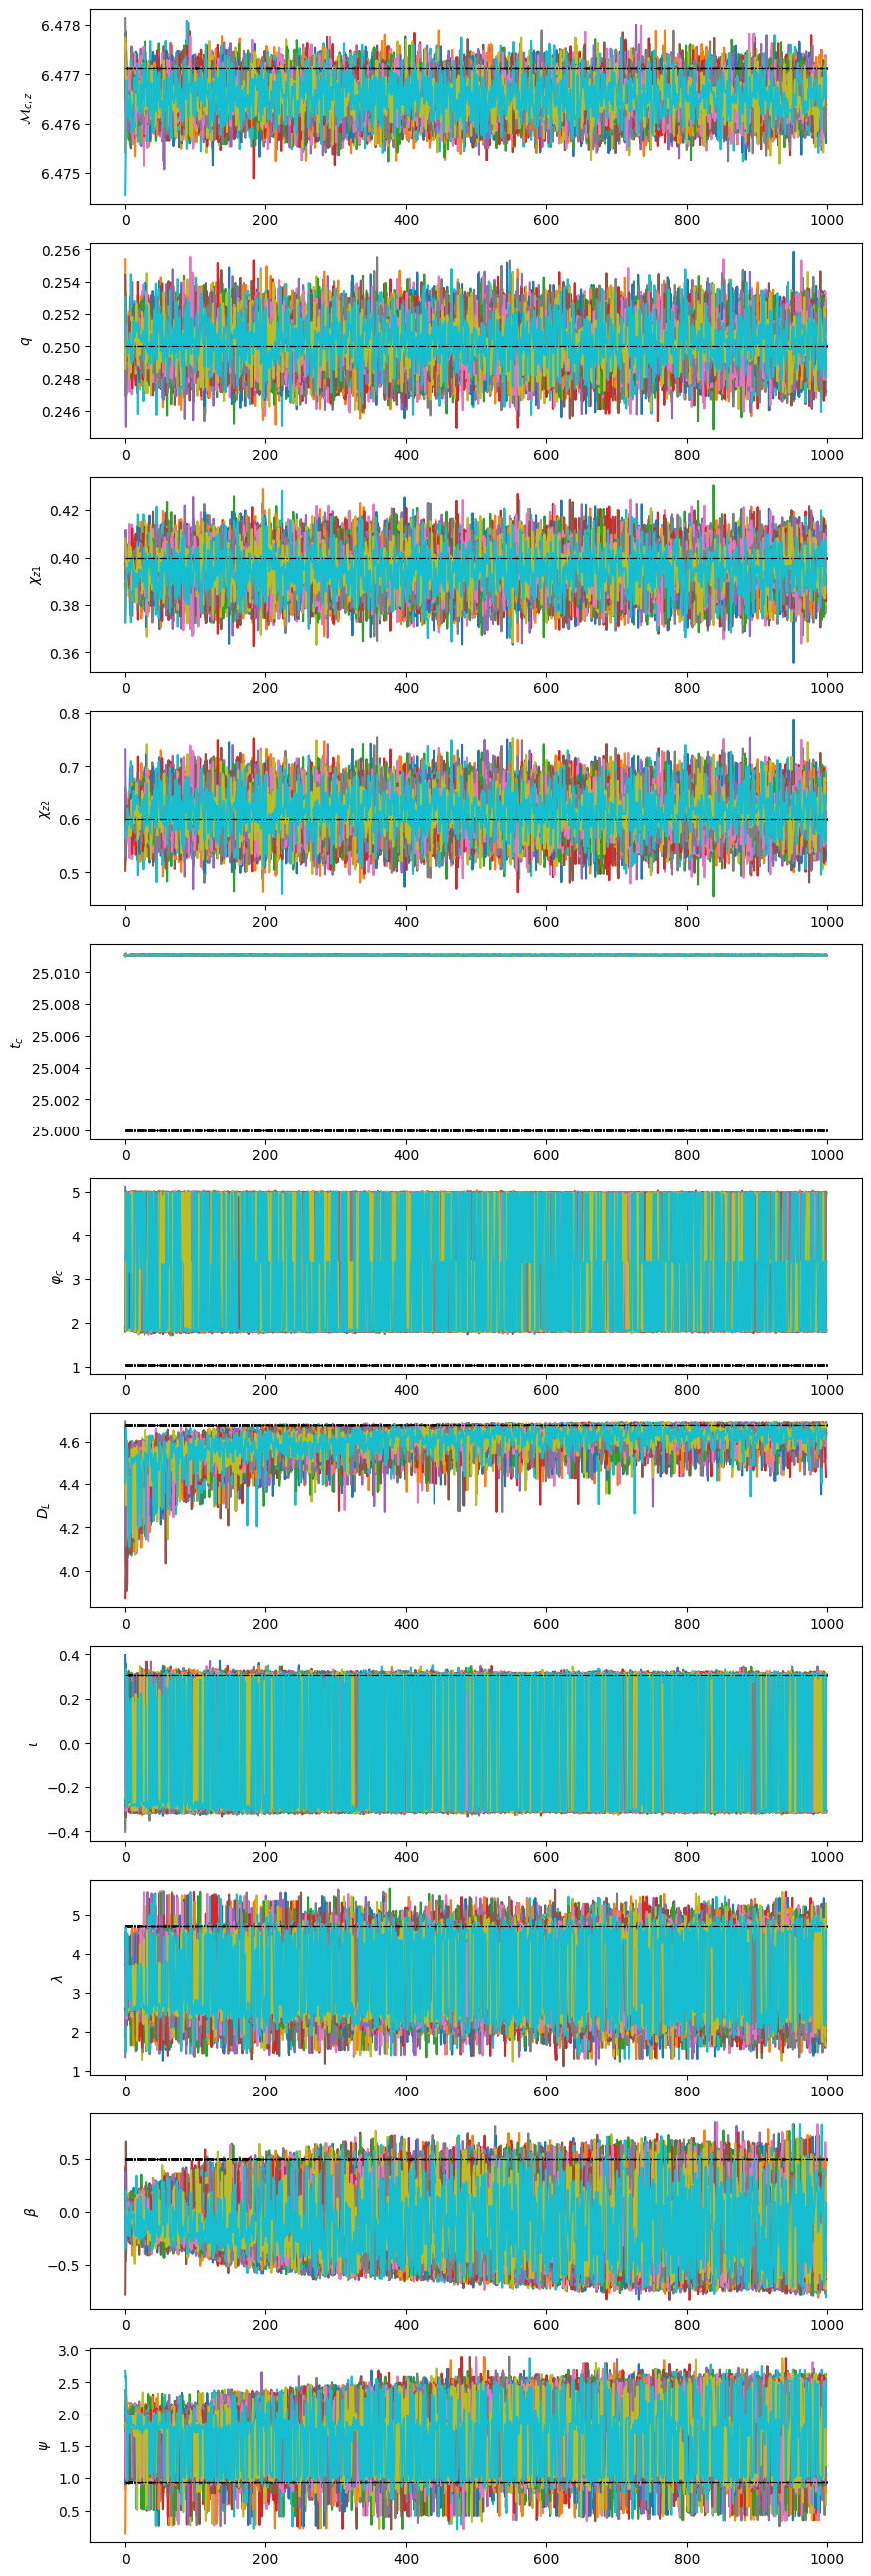

In [ ]:
thin = 1
burnin = 0
len_chain = len(ensemble.get_chain(thin=thin, discard=burnin)['model_0'][:, 0, 0, :, 0])

plt.figure()
fig, ax = plt.subplots(ndim, 1)
fig.set_size_inches(10, 3*ndim)
for i in range(ndim):     
    for walk in range(50): # plot 20 walkers 
        ax[i].plot(ensemble.get_chain(thin=thin, discard=burnin)['model_0'][:, 0, walk, 0, i])
        ax[i].hlines(injected_param_arr[i], 0, len_chain, color='k', linestyle='-.', linewidth=0.8)
    ax[i].set_ylabel(labels[i])


sample shape: (20000, 11)


<Figure size 640x480 with 0 Axes>

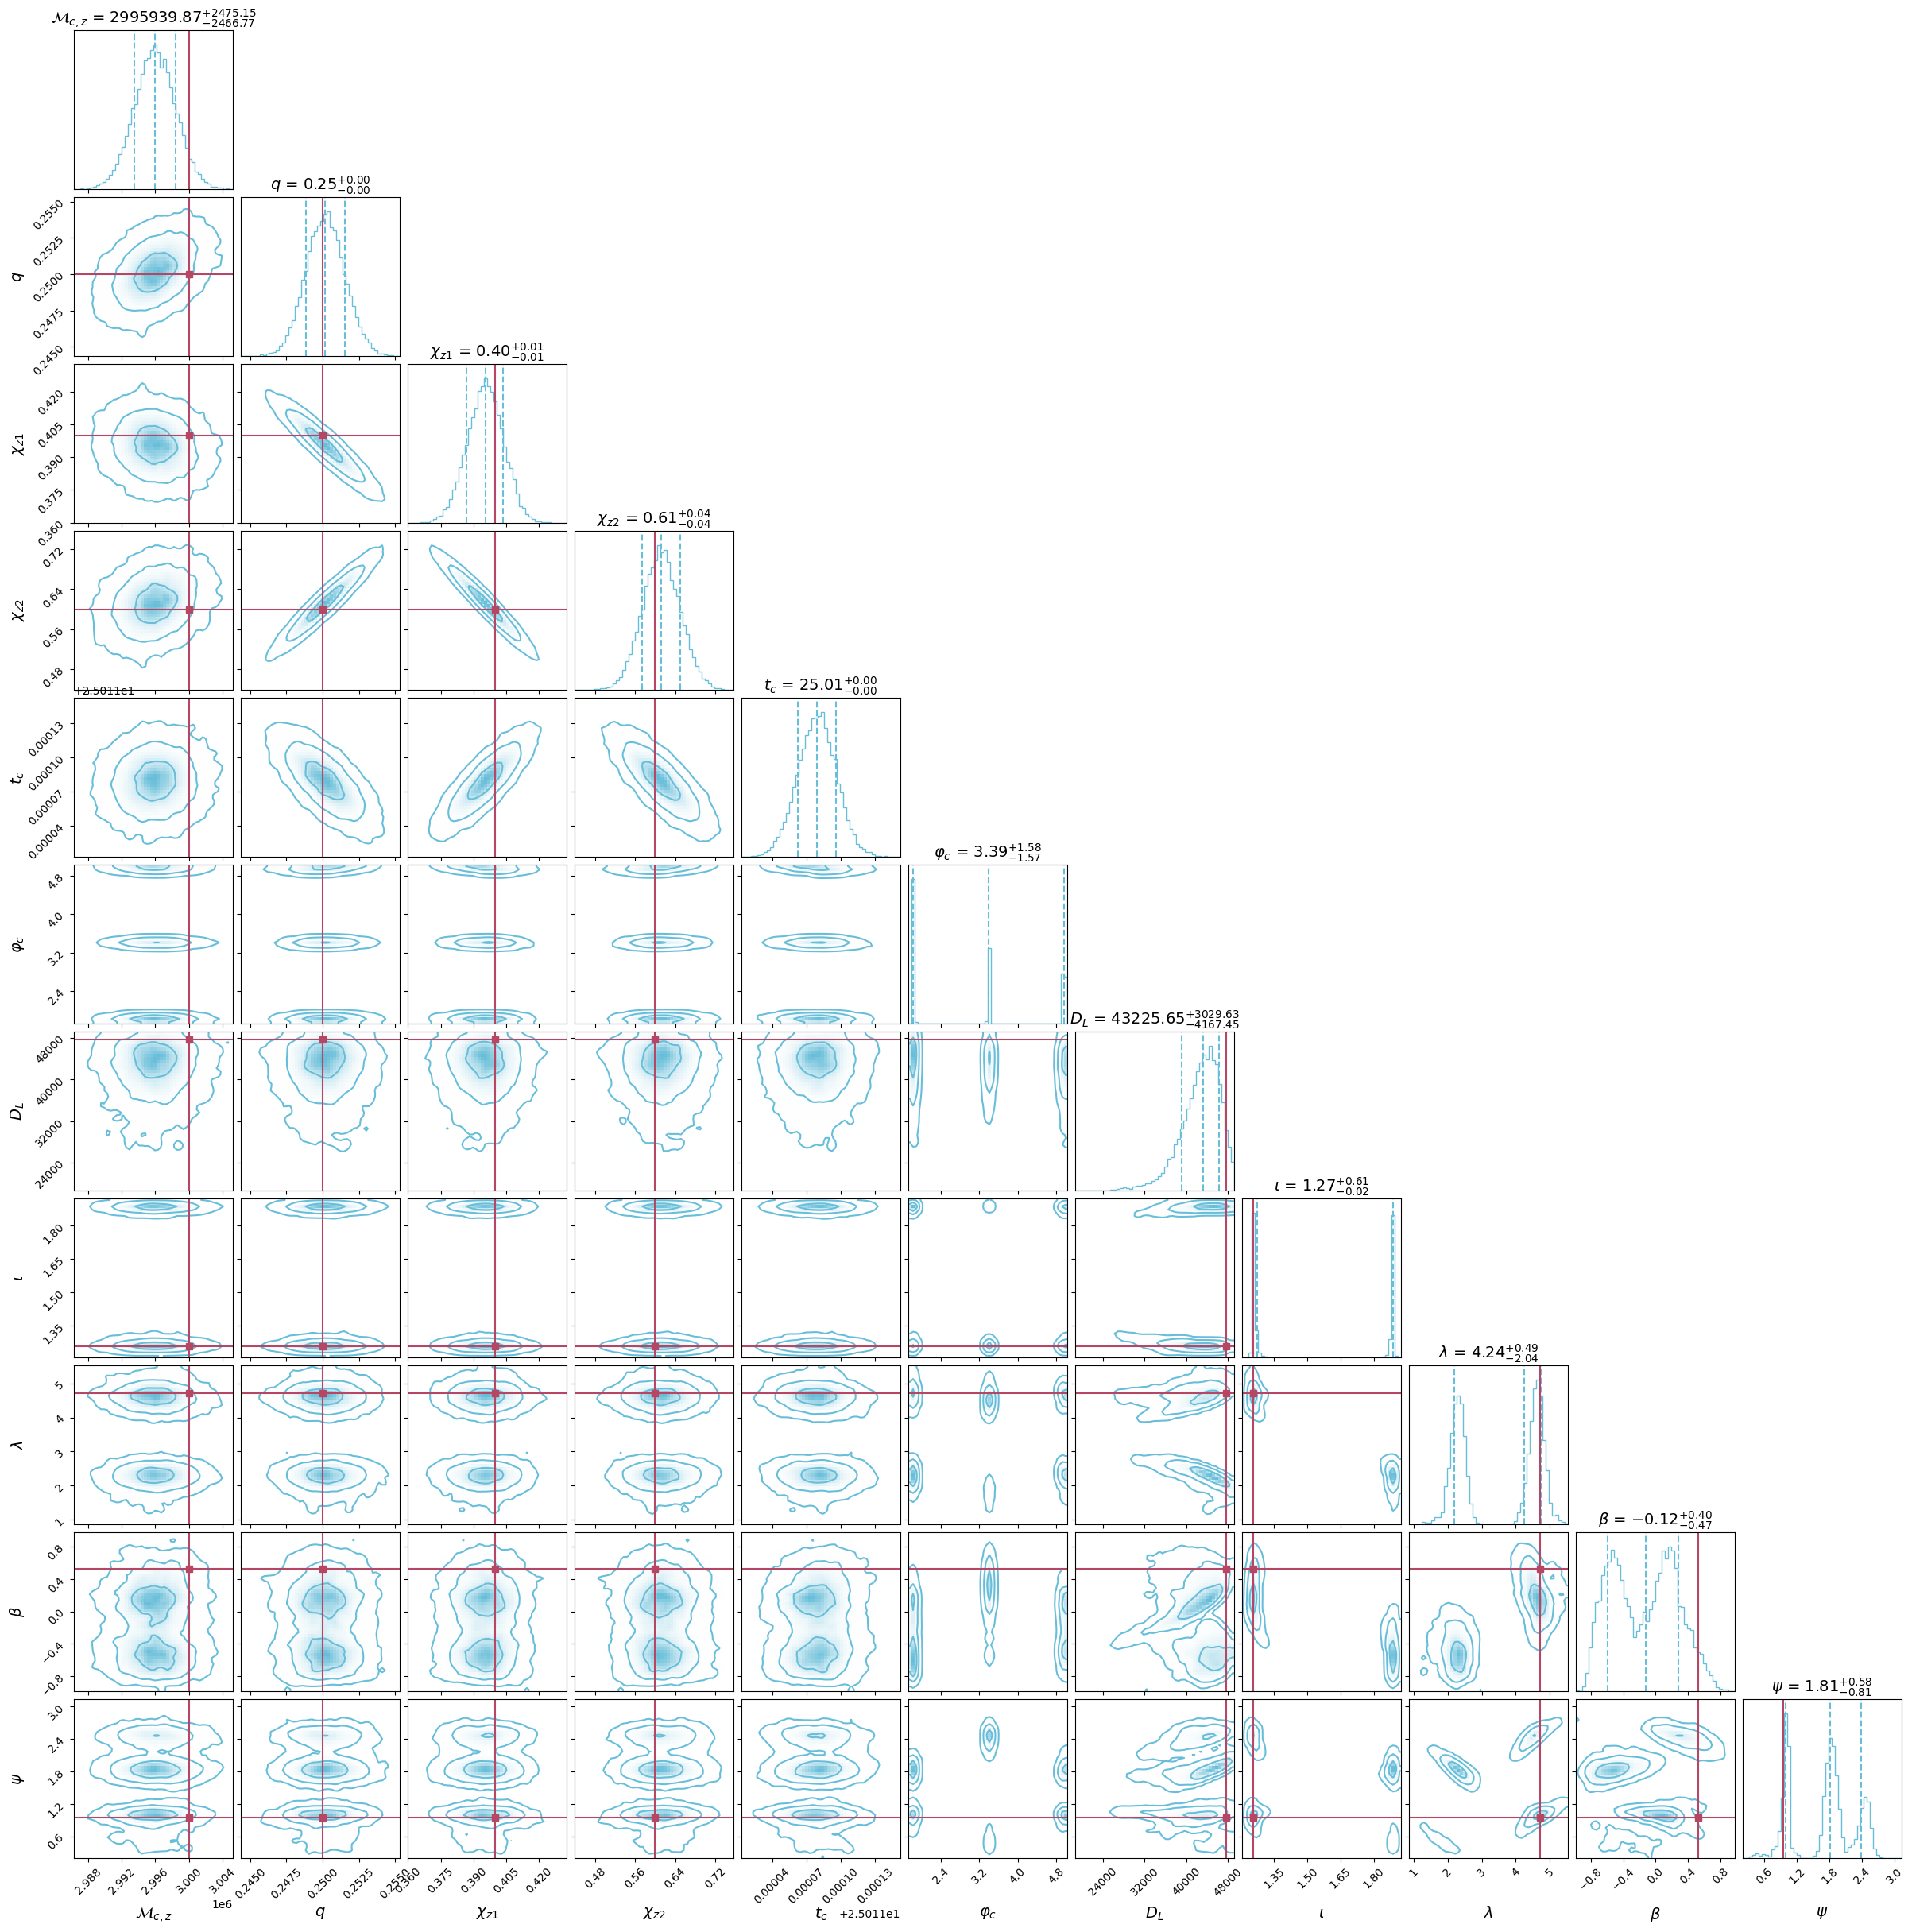

In [ ]:
burnin=500
thin = 10

samp = ensemble.get_chain(discard=burnin, thin=thin)['model_0'][:, 0, :, :, :].reshape(-1, ndim)
print("sample shape:", samp.shape)
# samp = samp[-10000:, :] # use the last 10000 points 

show_parameters = injected_parameters.copy()
show_parameters["coalescence_time"] = None 
show_parameters["coalescence_phase"] = None 
plt.figure()
corner(
    np.array(list(ParamArr2ParamDict(samp.T).values())).T, 
    bins=50, 
    color=BLUE, 
    labels=labels, 
    label_kwargs={'fontsize': 14}, 
    truths=np.array([show_parameters[key] for key in param_names]),
    truth_color=RED,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_kwargs={'fontsize':14},
    levels = (1. - np.exp(-1.**2/2), 1. - np.exp(-2.**2/2), 1. - np.exp(-3.**2/2)),
    smooth=0.9, # default for bilby: smooth = 0.9, bins = 50 
    plot_density=True, # whether to show the density of samples with colors 
    plot_datapoints=False, # whether to plot individual data points 
    fill_contours=False, # whether to fill the corners 
    );
with open("./Samples/posterior_gpu.pkl", "wb") as outfile: 
    pickle.dump(ParamArr2ParamDict(samp.T), outfile)

## Compare CPU and GPU results 

In [ ]:
import bilby 
cpu_posterior = bilby.result.read_in_result("Samples/vmbhb_example_result.json").posterior
num_cpu_samples = len(cpu_posterior["chirp_mass"])

with open("Samples/posterior_gpu.pkl", "rb") as infile: 
    gpu_posterior = pickle.load(infile)
num_gpu_samples = len(gpu_posterior["chirp_mass"])

num_samples = min(num_cpu_samples, num_gpu_samples)
for key in cpu_posterior.keys(): 
    cpu_posterior[key] = cpu_posterior[key][-num_samples:]
for key in gpu_posterior.keys(): 
    gpu_posterior[key] = gpu_posterior[key][-num_samples:]

cpu_posterior.pop("reference_time")
cpu_posterior.pop("reference_phase")
cpu_posterior.pop("log_likelihood")
cpu_posterior.pop("log_prior")
gpu_posterior.pop("coalescence_time")
gpu_posterior.pop("coalescence_phase")

cpu_samples = np.array([cpu_posterior[key] for key in cpu_posterior.keys()]).T 
gpu_samples = np.array([gpu_posterior[key] for key in cpu_posterior.keys()]).T 
cpu_samples.shape, gpu_samples.shape 

((6296, 9), (6296, 9))

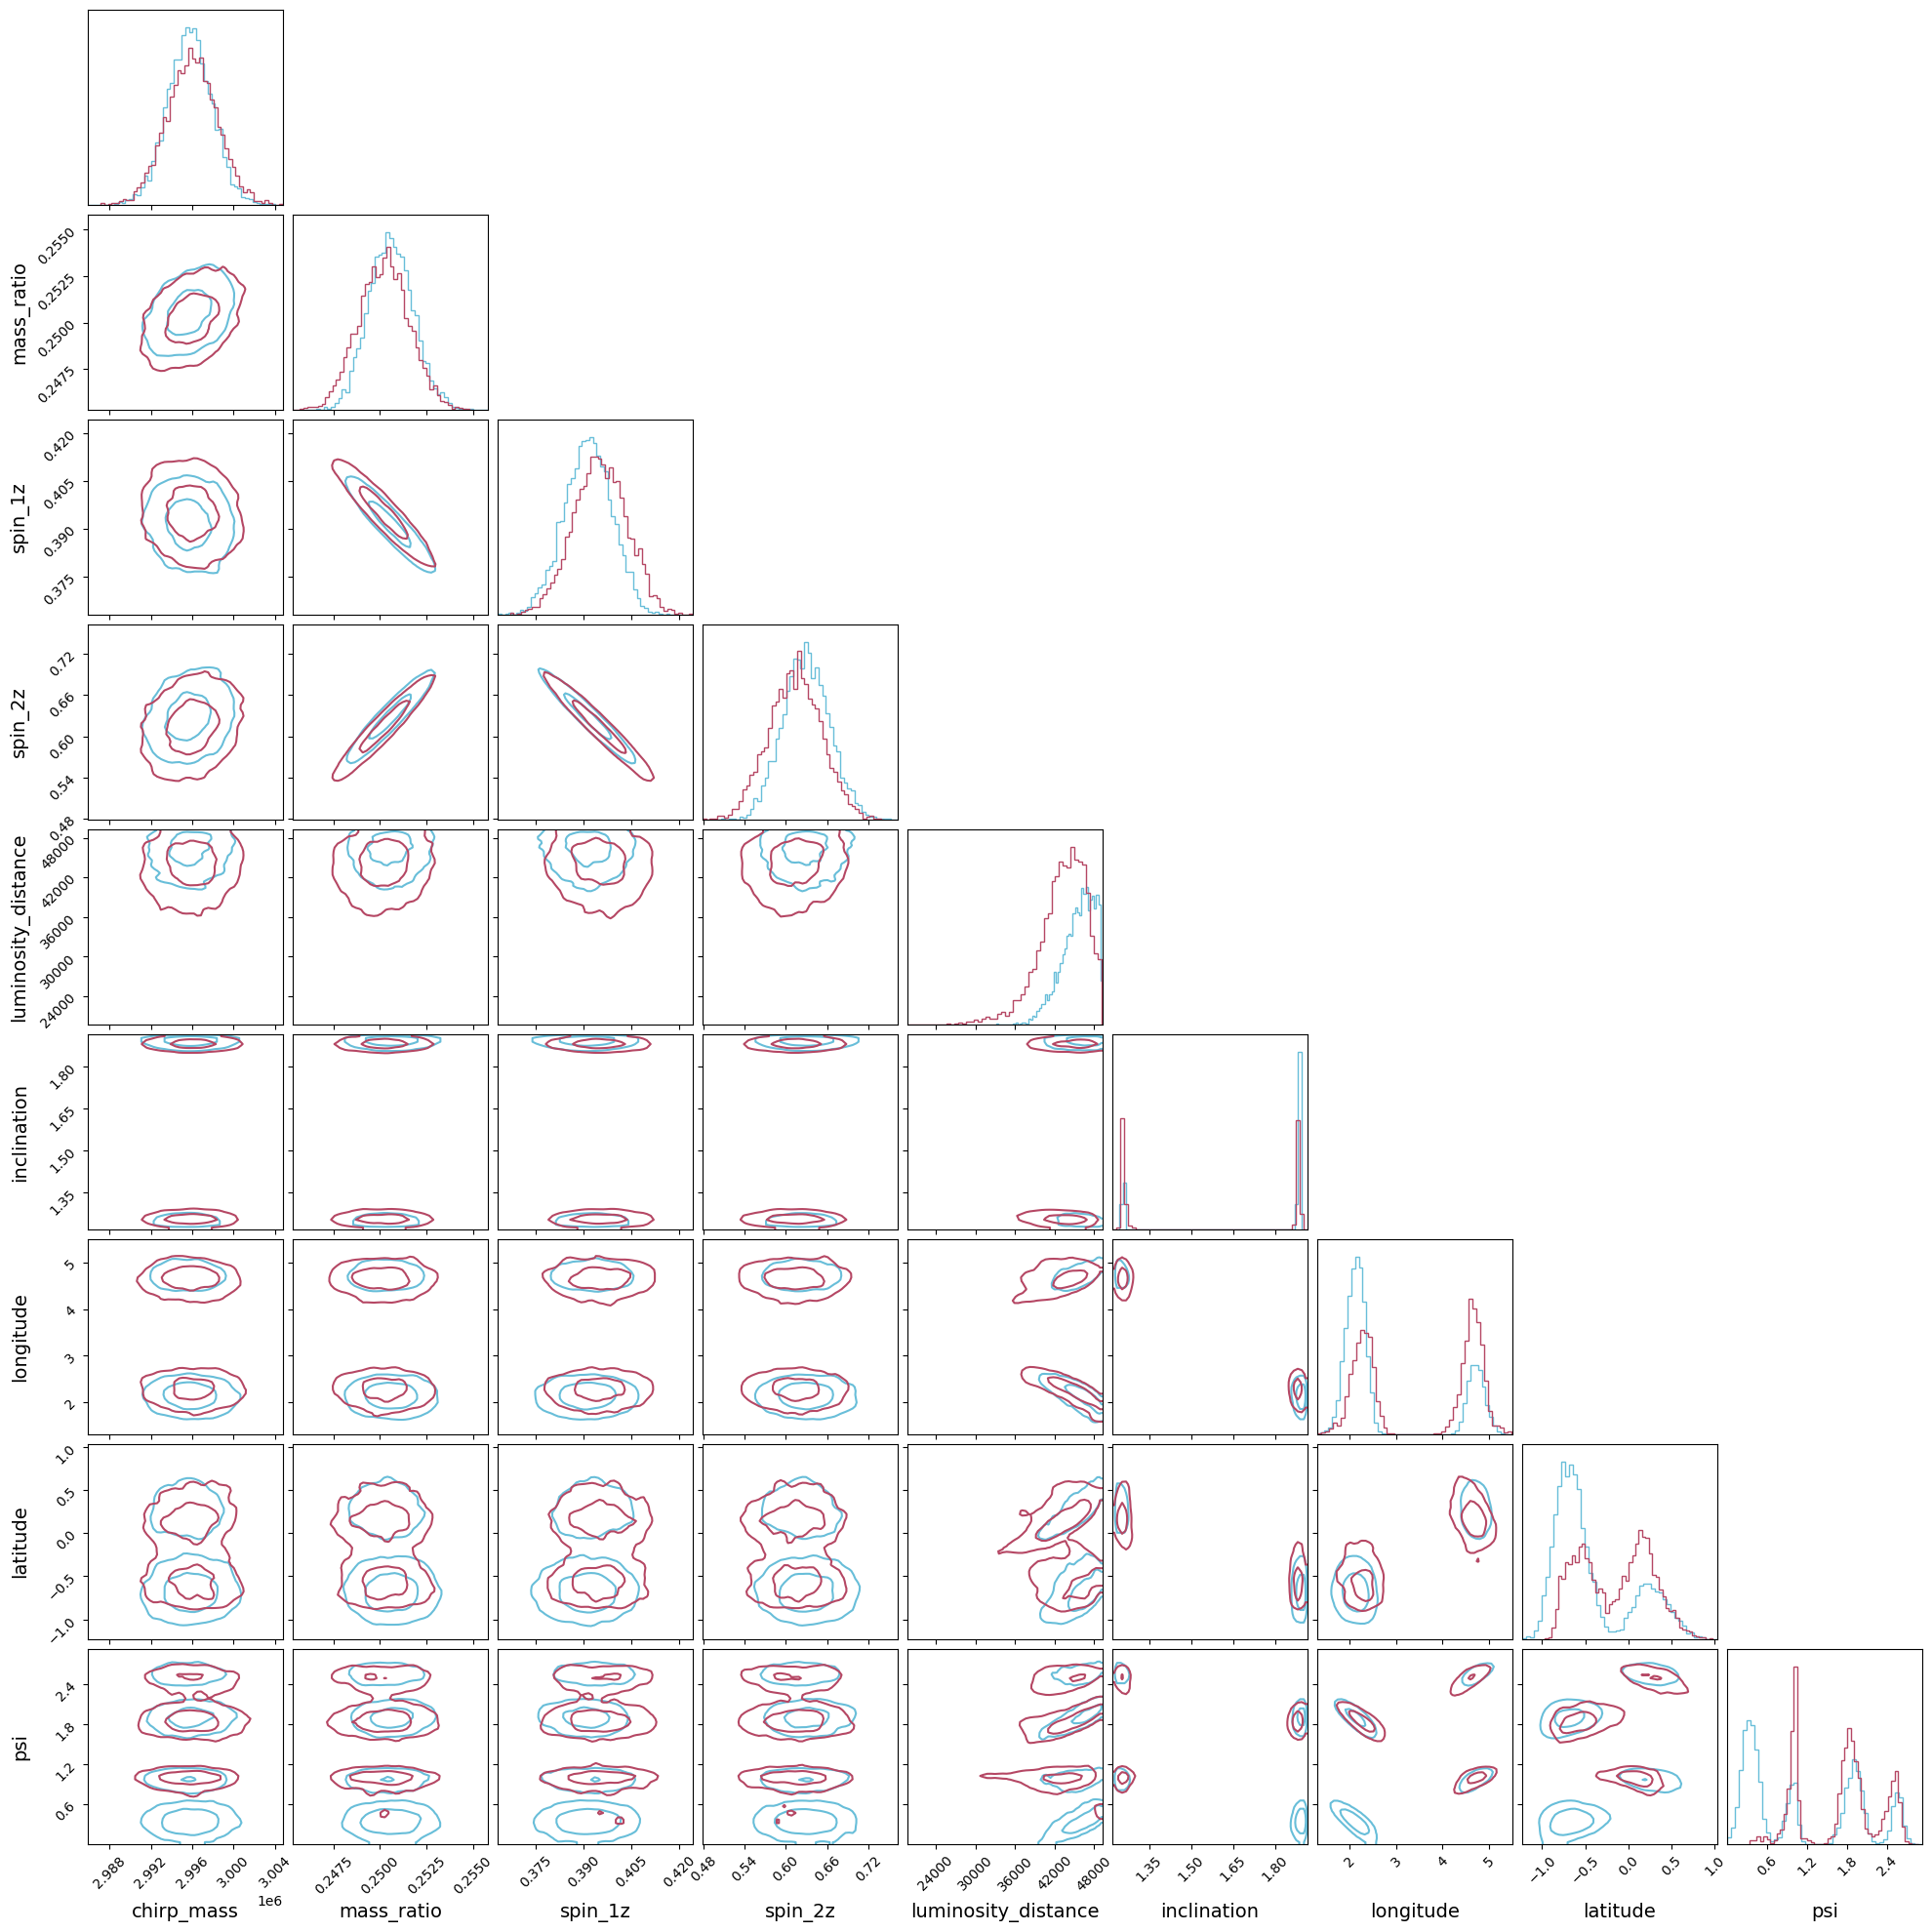

In [ ]:
fig = corner(
    cpu_samples, 
    bins=50, 
    color=BLUE, 
    labels=list(cpu_posterior.keys()), 
    label_kwargs={'fontsize': 14}, 
    levels = (1. - np.exp(-1.**2/2), 1. - np.exp(-2.**2/2)),
    smooth=1.1, # default for bilby: smooth = 0.9, bins = 50 
    plot_density=False, # whether to show the density of samples with colors 
    plot_datapoints=False, # whether to plot individual data points 
    fill_contours=False, # whether to fill the corners 
    );
fig = corner(
    gpu_samples, 
    bins=50, 
    color=RED, 
    levels = (1. - np.exp(-1.**2/2), 1. - np.exp(-2.**2/2)),
    smooth=1.1, # default for bilby: smooth = 0.9, bins = 50 
    plot_density=False, # whether to show the density of samples with colors 
    plot_datapoints=False, # whether to plot individual data points 
    fill_contours=False, # whether to fill the corners 
    fig=fig
    );